In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Project modules (since notebook is inside src/)
from data_loader import load_data
from classical_models import run_classical_svm, run_random_forest
from utils import print_section


In [31]:
print_section("Loading Dataset")

X_train, X_test, y_train, y_test, scaler = load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Loading Dataset
Training Shape: (242, 13)
Testing Shape: (61, 13)


In [32]:
#Training classical SVM
print_section("Classical SVM")

svm_acc, svm_model = run_classical_svm(
    X_train, X_test,
    y_train, y_test
)

print(f"SVM Accuracy: {svm_acc:.4f}")


Classical SVM
SVM Accuracy: 0.8033


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



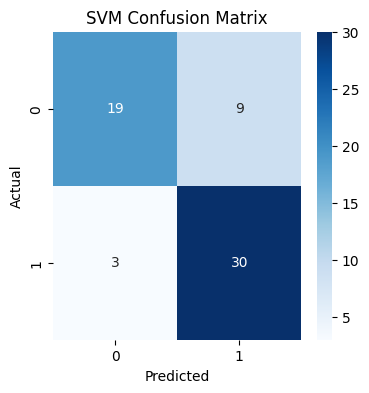

In [33]:
#SVM - Evaluation Metrics
y_pred_svm = svm_model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

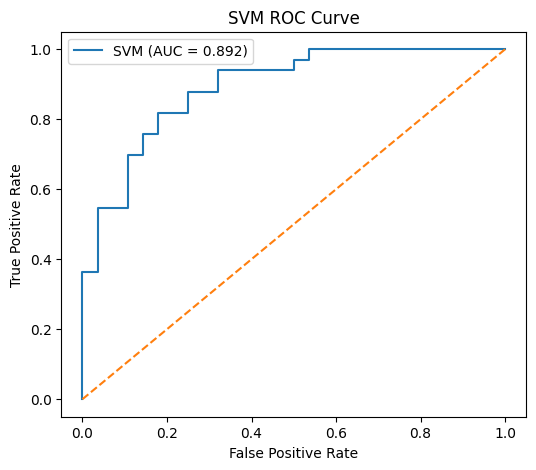

In [34]:
#SVM - ROC curve
# For ROC we need probabilities
svm_model.probability = True  # enable probability
svm_model.fit(X_train, y_train)

y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()


In [35]:
#Training Random Forest
print_section("Random Forest")
rf_model = run_random_forest(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_acc:.4f}")


Random Forest
Random Forest Accuracy: 0.8197


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



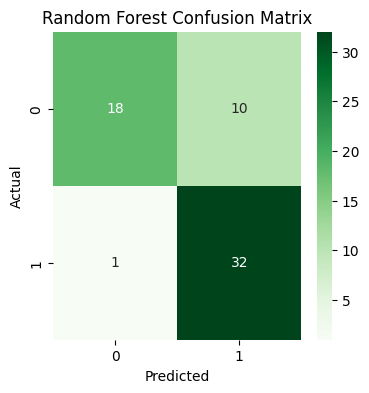

In [36]:
#RF - Evaluation metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(4,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

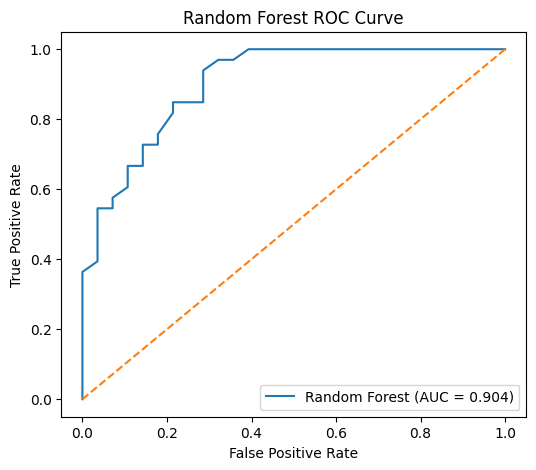

In [37]:
# RF - ROC curve
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()


Model Comparison
SVM Accuracy: 0.8033
Random Forest Accuracy: 0.8197


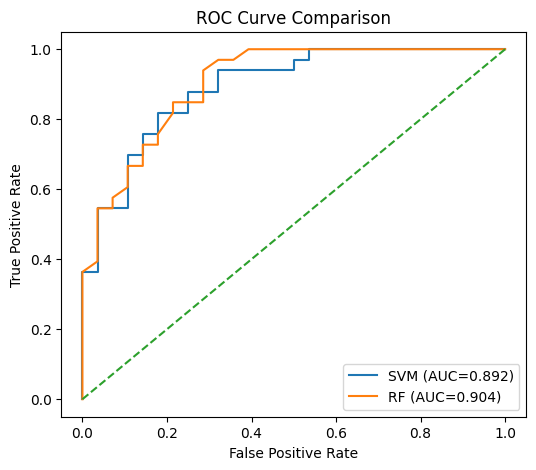

In [38]:
#Comparing models
print_section("Model Comparison")

print(f"SVM Accuracy: {svm_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"SVM (AUC={roc_auc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={roc_auc_rf:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()